# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [2]:
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)
adjust_extra_params = config.get_adjust_extra_params(rc.GAME_KEY, rc.NETWORK_KEY)   # <-- đổi từ game["adjust_extra_params"]
metabase_network_value = config.get_metabase_network_value(rc.NETWORK_KEY)          # <-- mới

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"   # không dùng nữa, xem cell Metabase bên dưới
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']} — network: {rc.NETWORK_KEY}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")

Đang chạy cho: Game C (BCE) — Android — network: ['applovin', 'unity']
Khoảng ngày: 2026-08-05 -> 2026-09-25


## 1. Lấy dữ liệu Metabase

In [3]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

# [CẬP NHẬT 2026-09-26] Card id=81 sửa lại phía owner (2026-09-24): "network",
# "game", "platform" giờ là Field Filter multi-select thật (không còn Plain
# Variable scalar) — PHẢI truyền value dạng LIST dù chỉ chọn 1 giá trị, nếu
# không Organic/game khác có thể lọt vào (đã xác nhận qua request thật tới
# API, xem ghi chú trong config.py cạnh NETWORK_OPTIONS).
parameters = mb.build_parameters(
    game["metabase_card_id"],
    cohort_date=metabase_date_range,       # "2026-08-01~2026-09-17" — Field Filter date/all-options
    network=metabase_network_value,        # list, VD ["APPLOVIN"] hoặc ["APPLOVIN","UNITY"]
    game=[game["metabase_game"]],          # list, VD ["Game C"] — không còn scalar
    platform=[game["metabase_platform"]],  # list, VD ["IOS"] — không còn scalar
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 190


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,Installs,CPI,Bid,...,Revenue Complete Through,Beta D1,Beta D3,Beta D7,Beta D14,Beta D28,Beta D30,BE Day,ROAS BEDay,BE Status
0,2026-09-25T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 AdROAS - 260422,769.803185,1886,1887,0.4080,0.659914,...,2026-09-25T00:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
1,2026-09-25T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 BLDROAS - 250829,373.969545,457,457,0.8183,0.679764,...,2026-09-25T00:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
2,2026-09-25T00:00:00Z,Game C,ANDROID,UNITY,BCE Android - D28 AdROAS - 260813,7.083371,29,29,0.2443,NaN,...,2026-09-25T00:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
3,2026-09-24T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 AdROAS - 260422,785.098910,1862,1868,0.4203,0.659905,...,2026-09-25T00:00:00Z,1.610578,NaN,NaN,NaN,NaN,NaN,None,None,None
4,2026-09-24T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 BLDROAS - 250829,665.899677,361,361,1.8446,0.679595,...,2026-09-25T00:00:00Z,1.805466,NaN,NaN,NaN,NaN,NaN,None,None,None


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [4]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),
    date_period=adjust_date_period,
    extra_params=adjust_extra_params,   # <-- đổi từ game["adjust_extra_params"]
)

print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 190
Totals: {'installs': 195738.0, 'network_cost': 164261.78, 'roas_cal_d0': 0.1066, 'roas_cal_d3': 0.2404, 'roas_cal_d7': 0.322, 'roas_cal_d14': 0.4032, 'roas_cal_d28': 0.5089, 'ad_revenue_total_cal_d0': 17126.8136, 'ad_revenue_total_cal_d3': 37095.3034, 'ad_revenue_total_cal_d7': 46223.5105, 'ad_revenue_total_cal_d14': 49363.0259, 'ad_revenue_total_cal_d28': 23284.8397, 'revenue_total_cal_d0': 388.787, 'revenue_total_cal_d3': 2123.649, 'revenue_total_cal_d7': 3840.495, 'revenue_total_cal_d14': 5634.407, 'revenue_total_cal_d28': 5181.428}


,day,network,campaign_network,installs,network_cost,roas_cal_d0,roas_cal_d3,roas_cal_d7,roas_cal_d14,roas_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28
0,2026-09-01,Unity,BCE Android - D28 AdROAS - 260813,6599,1330.8843,0.0564,0.1371,0.1875,0.2488,0.0,75.0396,180.4382,247.5717,327.1679,0.0,0.0,1.99,1.99,3.99,0.0
1,2026-09-06,ALV,BCE Android - D28 AdROAS - 260422,4753,1758.9883,0.123,0.2308,0.3165,0.3933,0.0,216.2894,405.9219,556.6864,691.7341,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-09-03,Unity,BCE Android - D28 BLDROAS - 260820,4469,2113.2731,0.0575,0.1274,0.1711,0.2101,0.0,121.4476,267.9015,359.6336,435.999,0.0,0.0,1.32,1.98,7.97,0.0
3,2026-09-02,Unity,BCE Android - D28 BLDROAS - 260820,4237,1624.6039,0.0528,0.1413,0.202,0.2783,0.0,85.7079,211.7205,291.9021,370.2173,0.0,0.0,17.853,36.293,81.894,0.0
4,2026-09-02,Unity,BCE Android - D28 AdROAS - 260813,4222,2274.2777,0.073,0.1637,0.2182,0.2667,0.0,166.0333,364.8967,488.8154,599.2217,0.0,0.0,7.36,7.36,7.36,0.0


In [5]:
'''from pathlib import Path
import pandas as pd

input_dir = Path("../outputs") / rc.GAME_KEY

# df_mb = pd.read_csv(input_dir / "mb.csv", encoding="utf-8-sig")
df_adjust = pd.read_csv(input_dir / "adj_0920.csv", encoding="utf-8-sig")'''

'from pathlib import Path\nimport pandas as pd\n\ninput_dir = Path("../outputs") / rc.GAME_KEY\n\n# df_mb = pd.read_csv(input_dir / "mb.csv", encoding="utf-8-sig")\ndf_adjust = pd.read_csv(input_dir / "adj_0920.csv", encoding="utf-8-sig")'

## 3. Normalize + loại ngày lỗi + Merge

In [6]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 189 dòng
Chỉ có ở Metabase: 1 dòng
Chỉ có ở Adjust: 1 dòng

⚠️ Chỉ có ở Metabase:
           date Campaign   Network
125  2026-09-07           APPLOVIN

⚠️ Chỉ có ở Adjust:
           date campaign_network network
128  2026-09-07          unknown     ALV


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [7]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-24
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 3247 dòng (= 191 cohort x 17 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 606


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D0,50,False,0.011971,0.0120,-0.000029,0.997583,-0.2417,OK
1,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D0,50,False,84.242516,86.2610,-2.018484,0.976600,-2.3400,OK
2,2026-08-05,APPLOVIN,BCE Android - D28 BLDROAS - 250829,AD_REVENUE_D0,50,False,66.572161,67.7820,-1.209839,0.982151,-1.7849,OK
3,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D14,50,False,0.011971,0.0120,-0.000029,0.997583,-0.2417,OK
4,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D14,50,False,325.660250,333.3062,-7.645950,0.977060,-2.2940,OK
5,2026-08-05,APPLOVIN,BCE Android - D28 BLDROAS - 250829,AD_REVENUE_D14,50,False,252.628988,256.6331,-4.004112,0.984398,-1.5602,OK
6,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D28,50,False,0.011971,0.0120,-0.000029,0.997583,-0.2417,OK
7,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D28,50,False,453.383177,462.0545,-8.671323,0.981233,-1.8767,OK
8,2026-08-05,APPLOVIN,BCE Android - D28 BLDROAS - 250829,AD_REVENUE_D28,50,False,322.699788,327.0108,-4.311012,0.986817,-1.3183,OK
9,2026-08-05,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D3,50,False,0.011971,0.0120,-0.000029,0.997583,-0.2417,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [8]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                          campaign          metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
 BCE Android - D28 AdROAS - 250827         ROAS_D0        1         0.0002      0.9970                 0.2980                   0.2980                0.2980           0.0000
 BCE Android - D28 AdROAS - 250827         ROAS_D3        1         0.0002      0.9970                 0.2980                   0.2980                0.2980           0.0000
 BCE Android - D28 AdROAS - 250827         ROAS_D7        1         0.0002      0.9970                 0.2980                   0.2980                0.2980           0.0000
 BCE Android - D28 AdROAS - 250827        ROAS_D14        1         0.0002      0.9970                 0.2980                   0.2980                0.2980           0.0000
 BCE Android - D28 AdROAS - 250827        ROAS_D28        1         0.0002      0.9970        

In [9]:
print([c for c in merged.columns if "ad_revenue" in c or "revenue_total" in c])

['ad_revenue_total_cal_d0_mb', 'ad_revenue_total_cal_d1', 'ad_revenue_total_cal_d3_mb', 'ad_revenue_total_cal_d7_mb', 'ad_revenue_total_cal_d14_mb', 'ad_revenue_total_cal_d28_mb', 'ad_revenue_total_cal_d30', 'revenue_total_cal_d0_mb', 'revenue_total_cal_d1', 'revenue_total_cal_d3_mb', 'revenue_total_cal_d7_mb', 'revenue_total_cal_d14_mb', 'revenue_total_cal_d28_mb', 'revenue_total_cal_d30', 'ad_revenue_total_cal_d0_adj', 'ad_revenue_total_cal_d3_adj', 'ad_revenue_total_cal_d7_adj', 'ad_revenue_total_cal_d14_adj', 'ad_revenue_total_cal_d28_adj', 'revenue_total_cal_d0_adj', 'revenue_total_cal_d3_adj', 'revenue_total_cal_d7_adj', 'revenue_total_cal_d14_adj', 'revenue_total_cal_d28_adj']


## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [10]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
1088,2026-08-25,UNITY,BCE Android - D28 BLDROAS - 260820,ROAS_D14,0.043129,0.0072,0.035929,499.0106
1093,2026-08-25,UNITY,BCE Android - D28 BLDROAS - 260820,ROAS_D28,0.043129,0.0072,0.035929,499.0106
1028,2026-08-25,UNITY,BCE Android - D28 BLDROAS - 260820,AD_REVENUE_D14,3.918610,0.6558,3.262810,497.5313
1033,2026-08-25,UNITY,BCE Android - D28 BLDROAS - 260820,AD_REVENUE_D28,3.918610,0.6558,3.262810,497.5313
415,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D14,0.000445,0.0006,-0.000155,-25.7702
424,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D7,0.000445,0.0006,-0.000155,-25.7702
421,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D3,0.000445,0.0006,-0.000155,-25.7702
412,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D0,0.000445,0.0006,-0.000155,-25.7702
418,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D28,0.000445,0.0006,-0.000155,-25.7702
376,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,AD_REVENUE_D0,0.000160,0.0002,-0.000040,-20.0000



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
257,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D14,120.776484,143.5422,-22.765716,-15.8599
281,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,ROAS_D14,0.328583,0.3905,-0.061917,-15.8558
283,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,ROAS_D28,0.391882,0.4564,-0.064518,-14.1363
259,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D28,144.042968,167.7491,-23.706132,-14.1319
263,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D7,98.904708,114.3572,-15.452492,-13.5125
415,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D14,0.000445,0.0006,-0.000155,-25.7702
424,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D7,0.000445,0.0006,-0.000155,-25.7702
421,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D3,0.000445,0.0006,-0.000155,-25.7702
412,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D0,0.000445,0.0006,-0.000155,-25.7702
418,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D28,0.000445,0.0006,-0.000155,-25.7702


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [11]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

df_mb.to_csv(output_dir / "mb.csv", index=False, encoding="utf-8-sig")
df_adjust.to_csv(output_dir / "adj.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_android


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
           metric      mb_total  adjust_total   n  rel_diff_pct
    AD_REVENUE_D0  16488.746022    16987.9614 186     -2.938642
    AD_REVENUE_D3  34616.659378    35693.7948 177     -3.017711
    AD_REVENUE_D7  42020.889711    43356.9860 165     -3.081617
   AD_REVENUE_D14  44139.345004    45581.2443 142     -3.163361
   AD_REVENUE_D28  17142.056474    17640.1829  75     -2.823817
   IAP_REVENUE_D0    379.592000      379.5920  45      0.000000
   IAP_REVENUE_D3   2017.843000     2017.8430  79      0.000000
   IAP_REVENUE_D7   3683.246000     3683.2460  78      0.000000
  IAP_REVENUE_D14   5168.045000     5168.0450  71      0.000000
  IAP_REVENUE_D28   4545.481000     4545.4810  36      0.000000
             COST 164262.555894   164261.7803 189      0.000472
         INSTALLS 194925.000000   195737.0000 189     -0.414842
 TOTAL_REVENUE_D0   8021.592048     8273.1145  45     -3.040239
 TOTAL_REVENUE_D3  27398.189586    28237.4600  79   

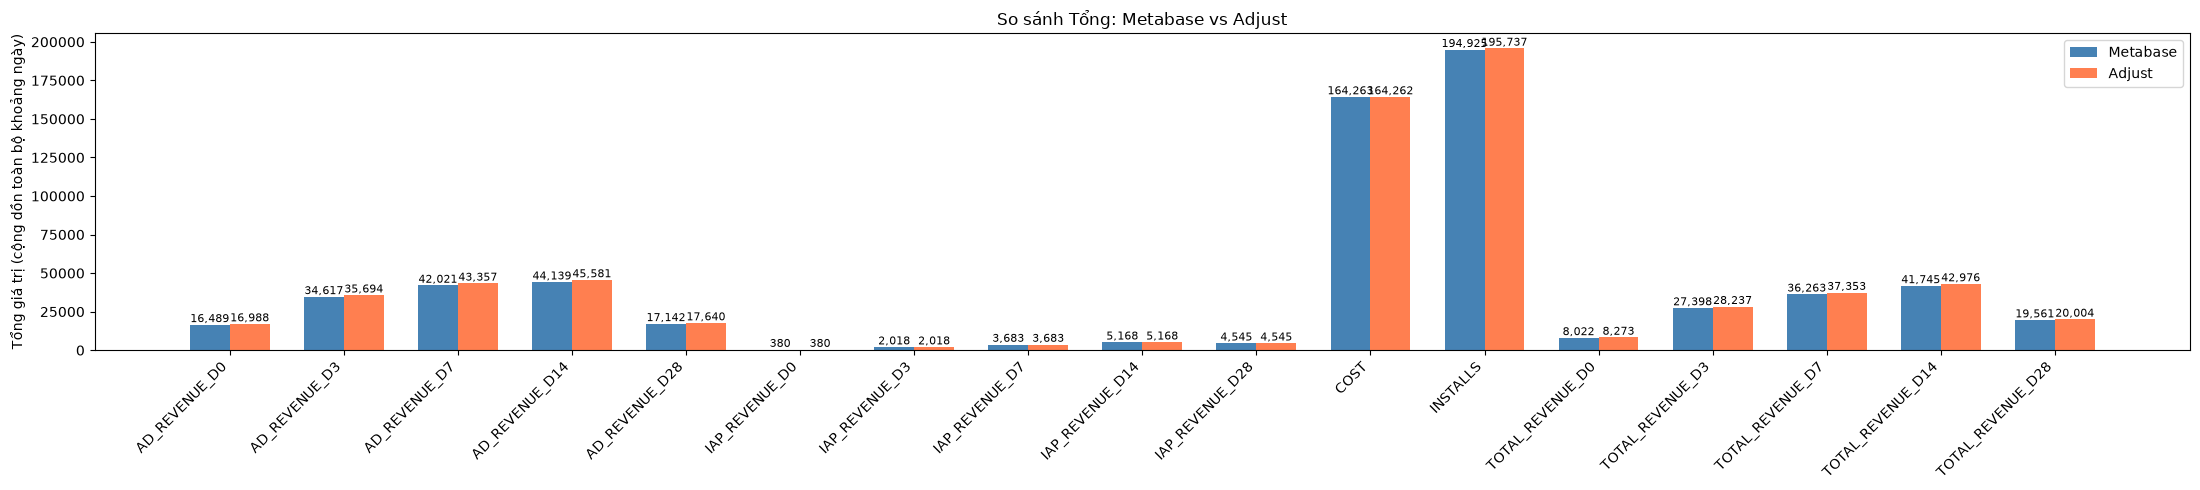

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_android\reconciliation_totals_comparison.csv


In [12]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)


print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

In [13]:
import reconciliation.eda as eda
print(eda.SUMMABLE_METRICS)

['COST', 'INSTALLS', 'AD_REVENUE_D0', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'IAP_REVENUE_D0', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28']


In [14]:
print(sorted(detail["metric"].unique()))

['AD_REVENUE_D0', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'COST', 'IAP_REVENUE_D0', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'INSTALLS', 'ROAS_D0', 'ROAS_D14', 'ROAS_D28', 'ROAS_D3', 'ROAS_D7']


### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 8
                                    n_days  first_date   last_date
campaign                                                          
BCE Android - D28 AdROAS - 260422       52  2026-08-05  2026-09-25
BCE Android - D28 BLDROAS - 250829      52  2026-08-05  2026-09-25
BCE Android - D28 AdROAS - 260813       43  2026-08-14  2026-09-25
BCE Android - D28 BLDROAS - 260820      23  2026-08-20  2026-09-12
BCE Android - D7 AdROAS - 260817        18  2026-08-19  2026-09-08
BCE Android - D28 AdROAS - 250827        1  2026-08-05  2026-08-05
                                         1  2026-09-07  2026-09-07
unknown                                  1  2026-09-07  2026-09-07


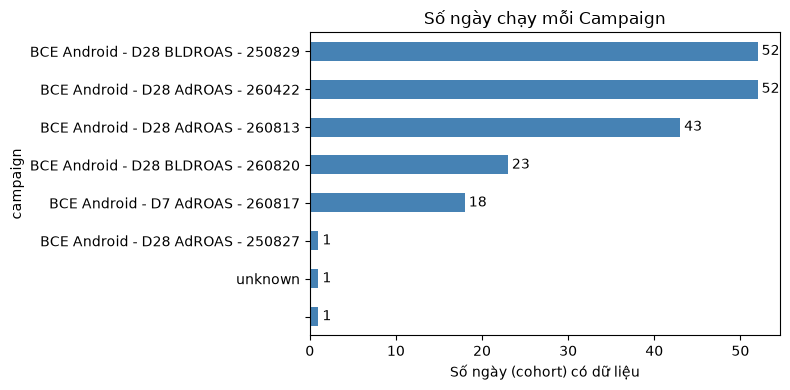

In [15]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

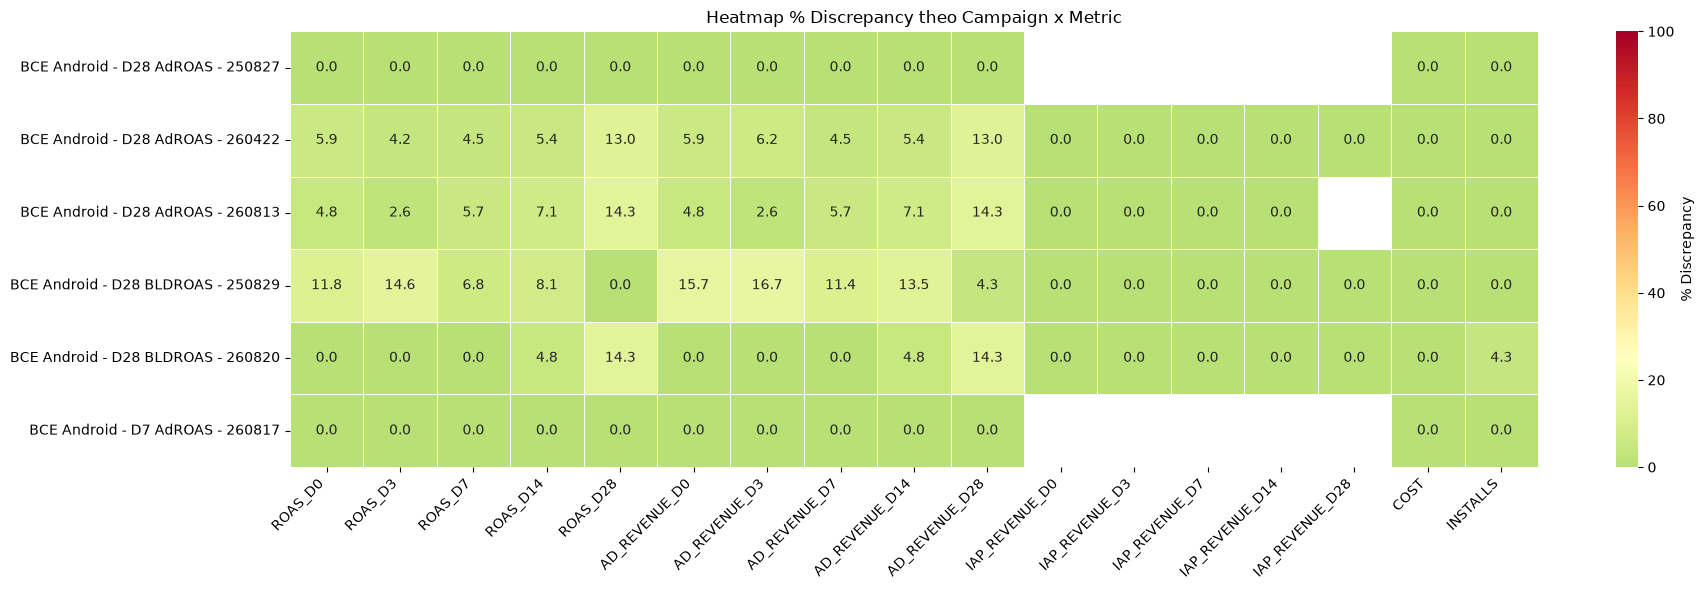

In [16]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

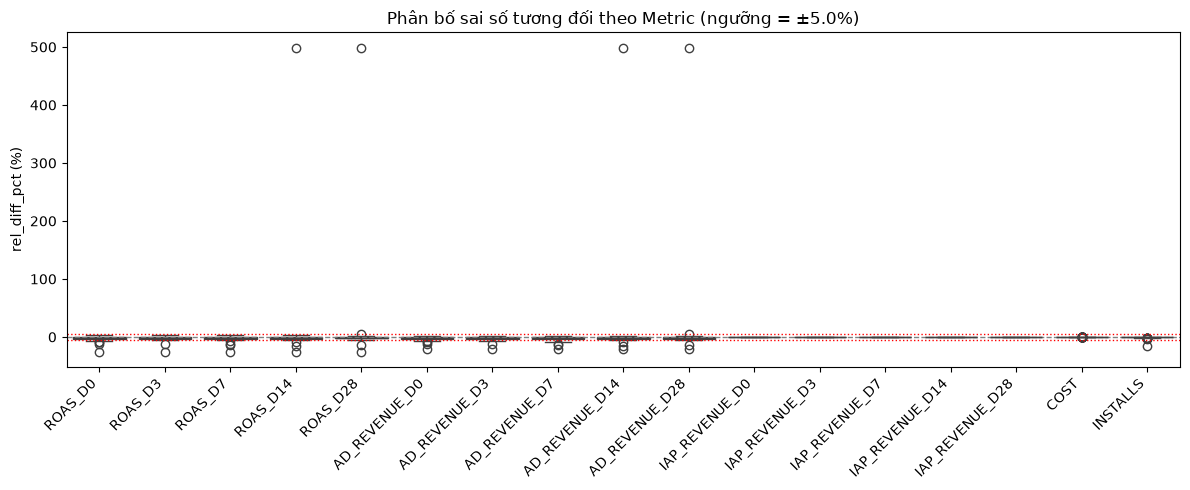

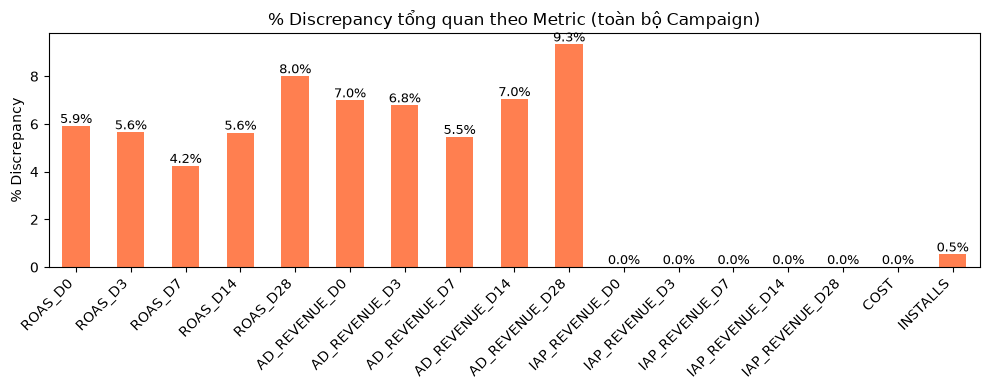

In [17]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

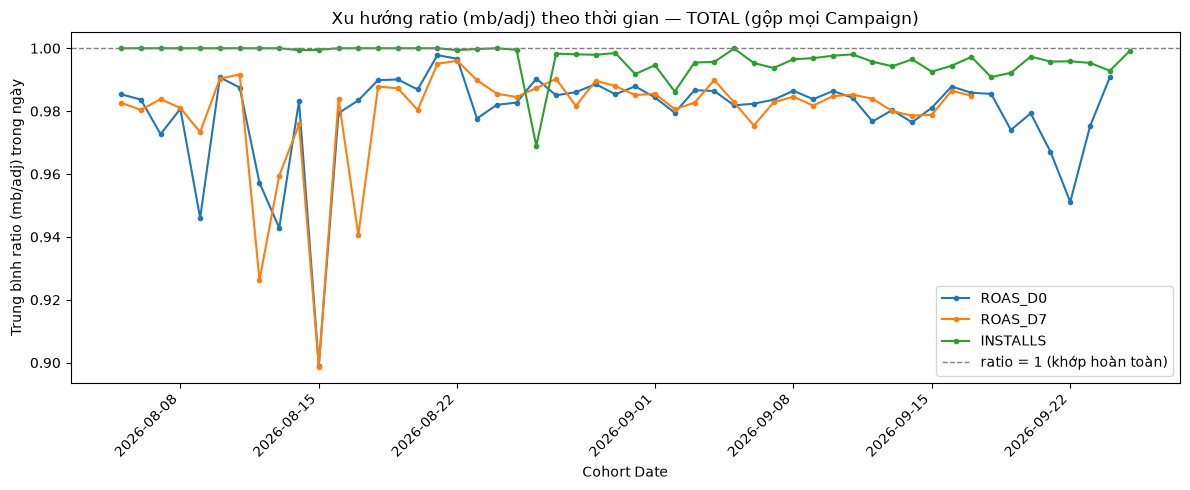

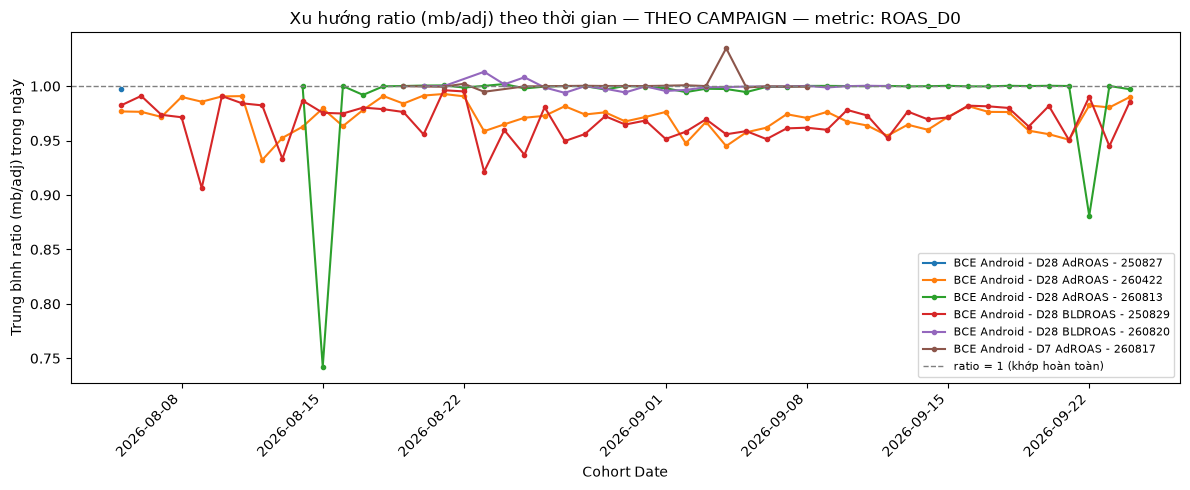

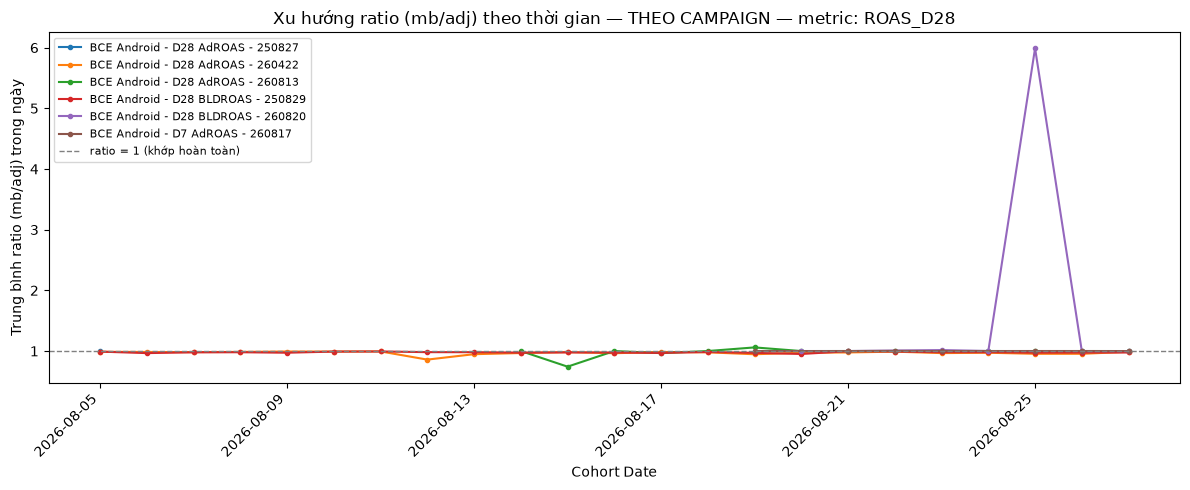

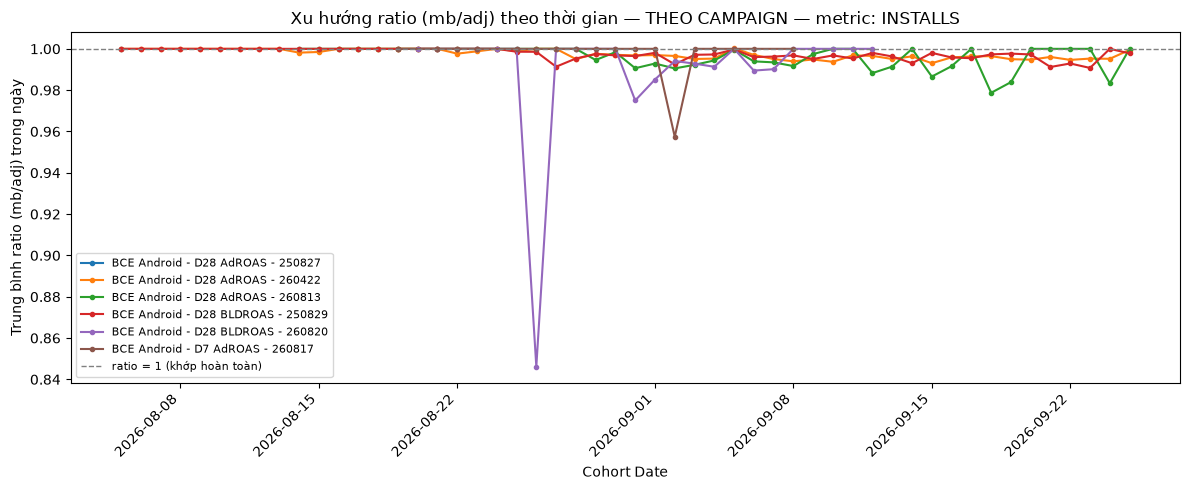

In [18]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D28")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

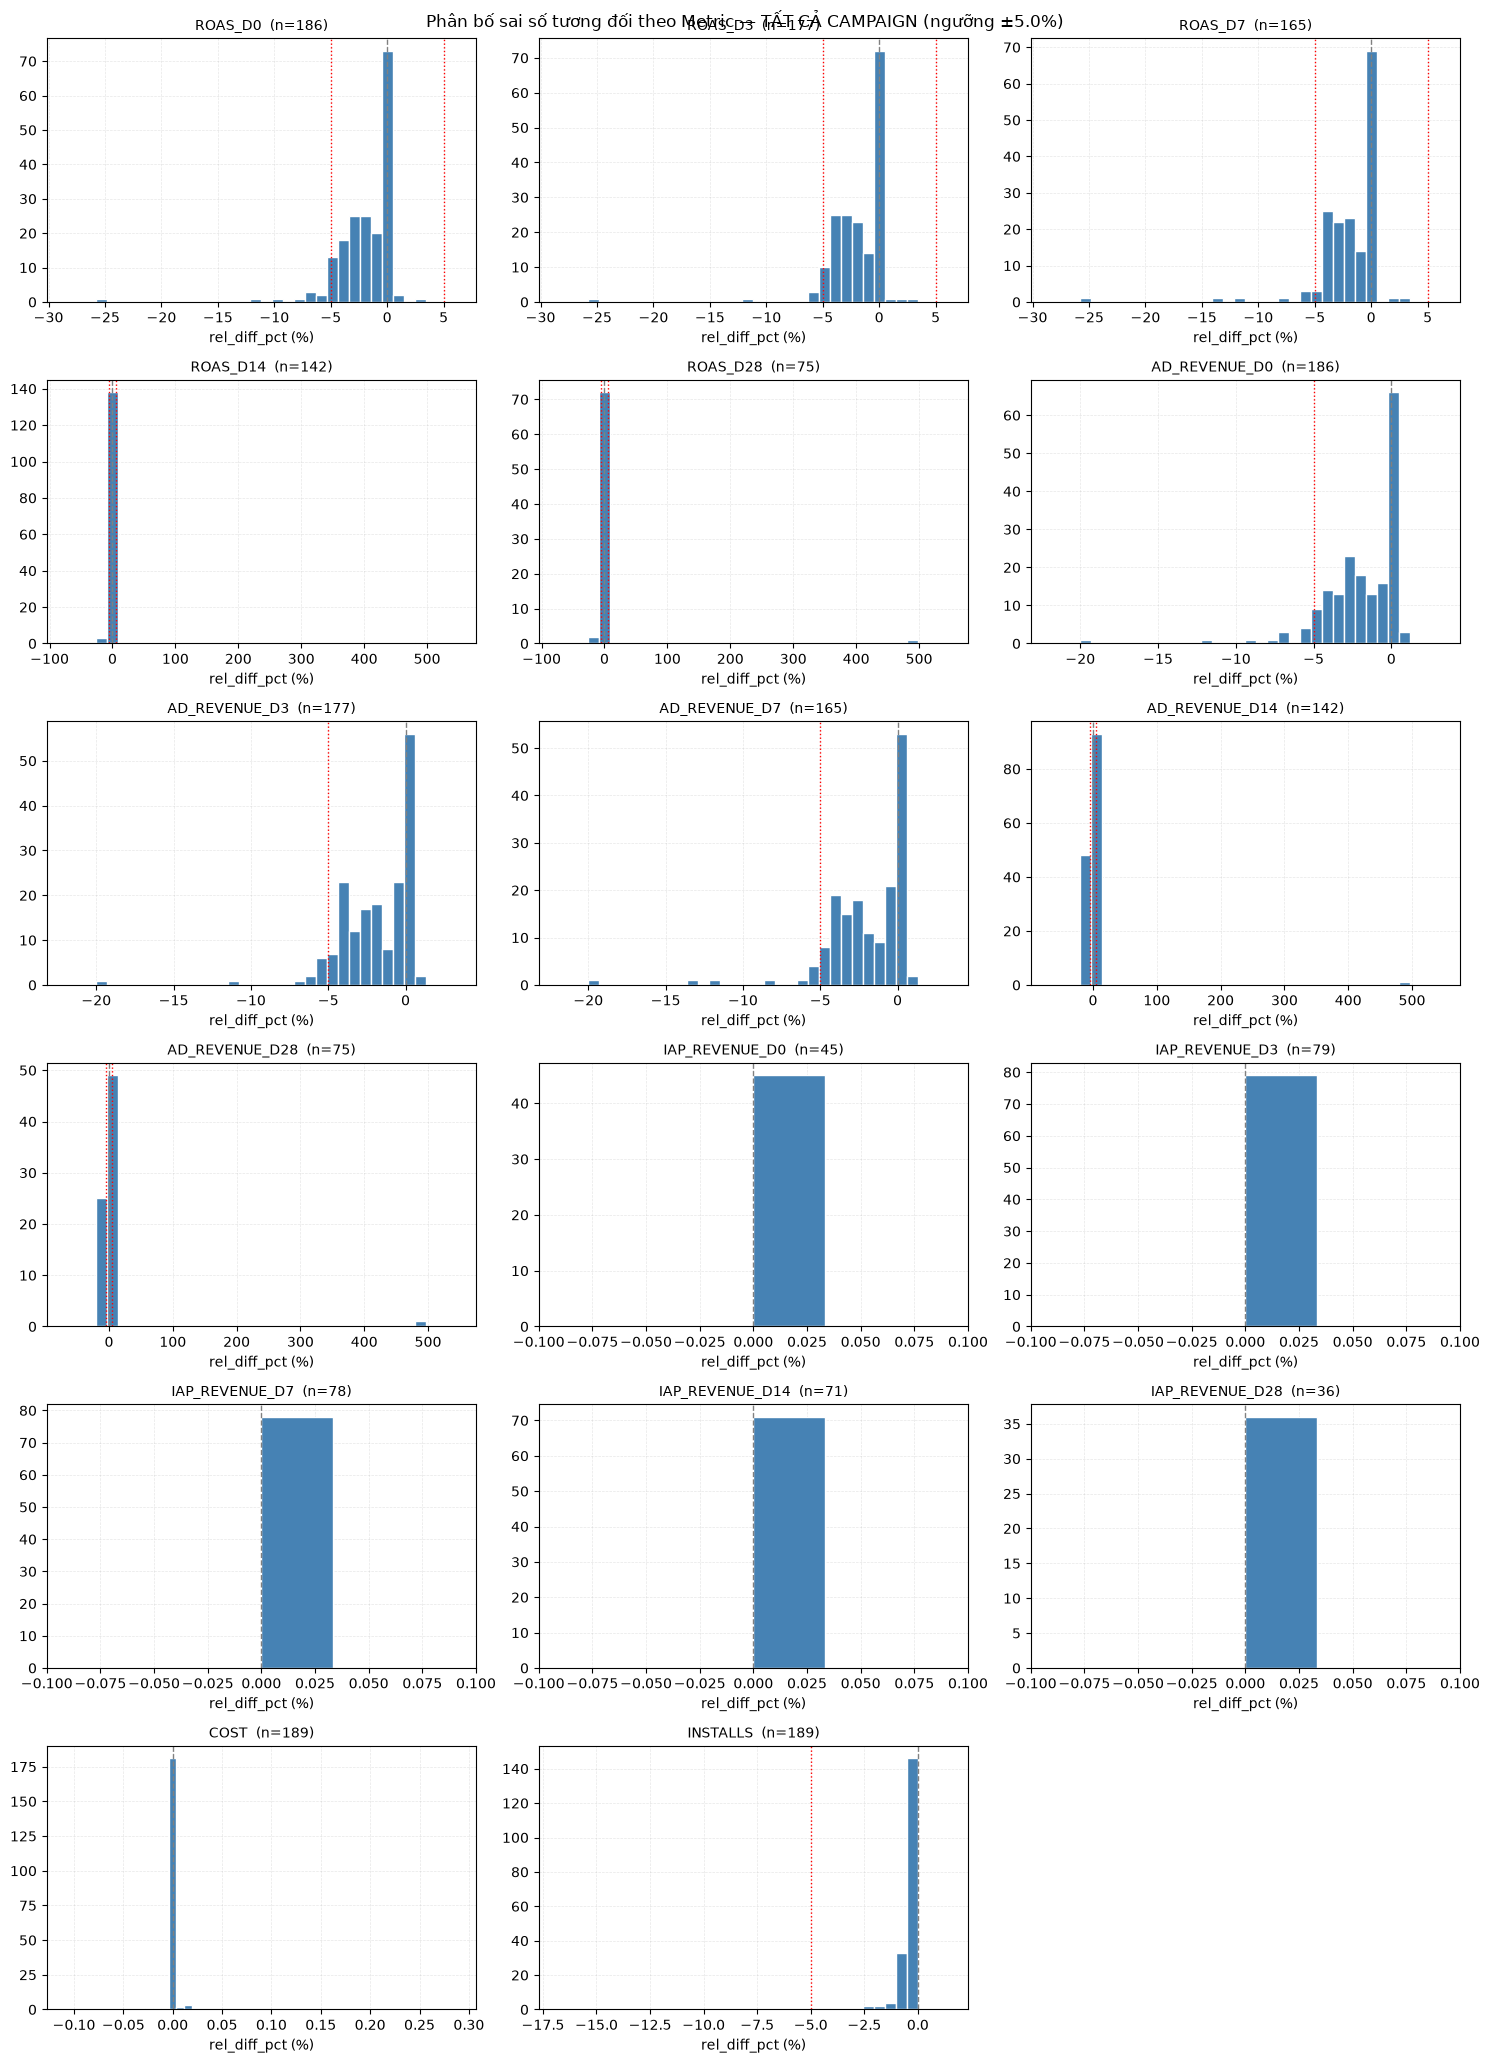

In [19]:
eda.plot_rel_diff_histogram(detail)

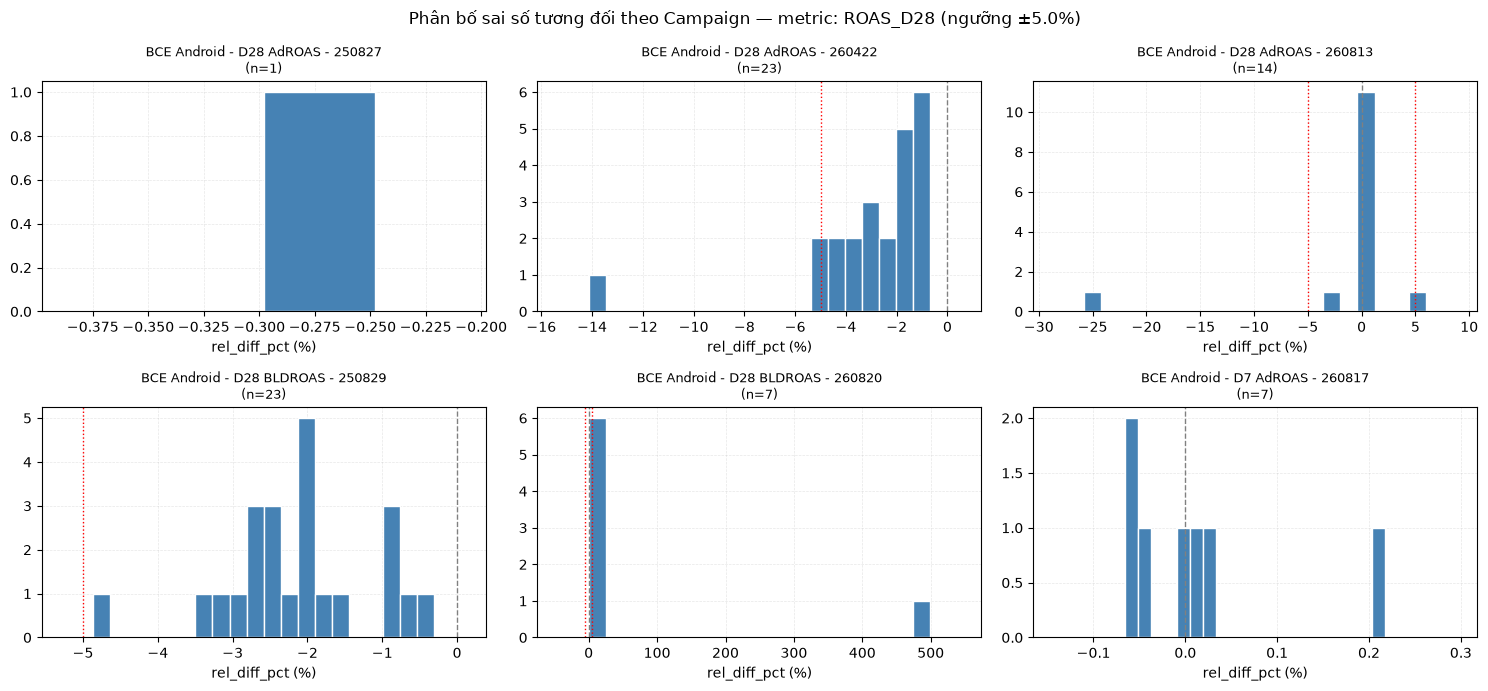

In [20]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="ROAS_D28")

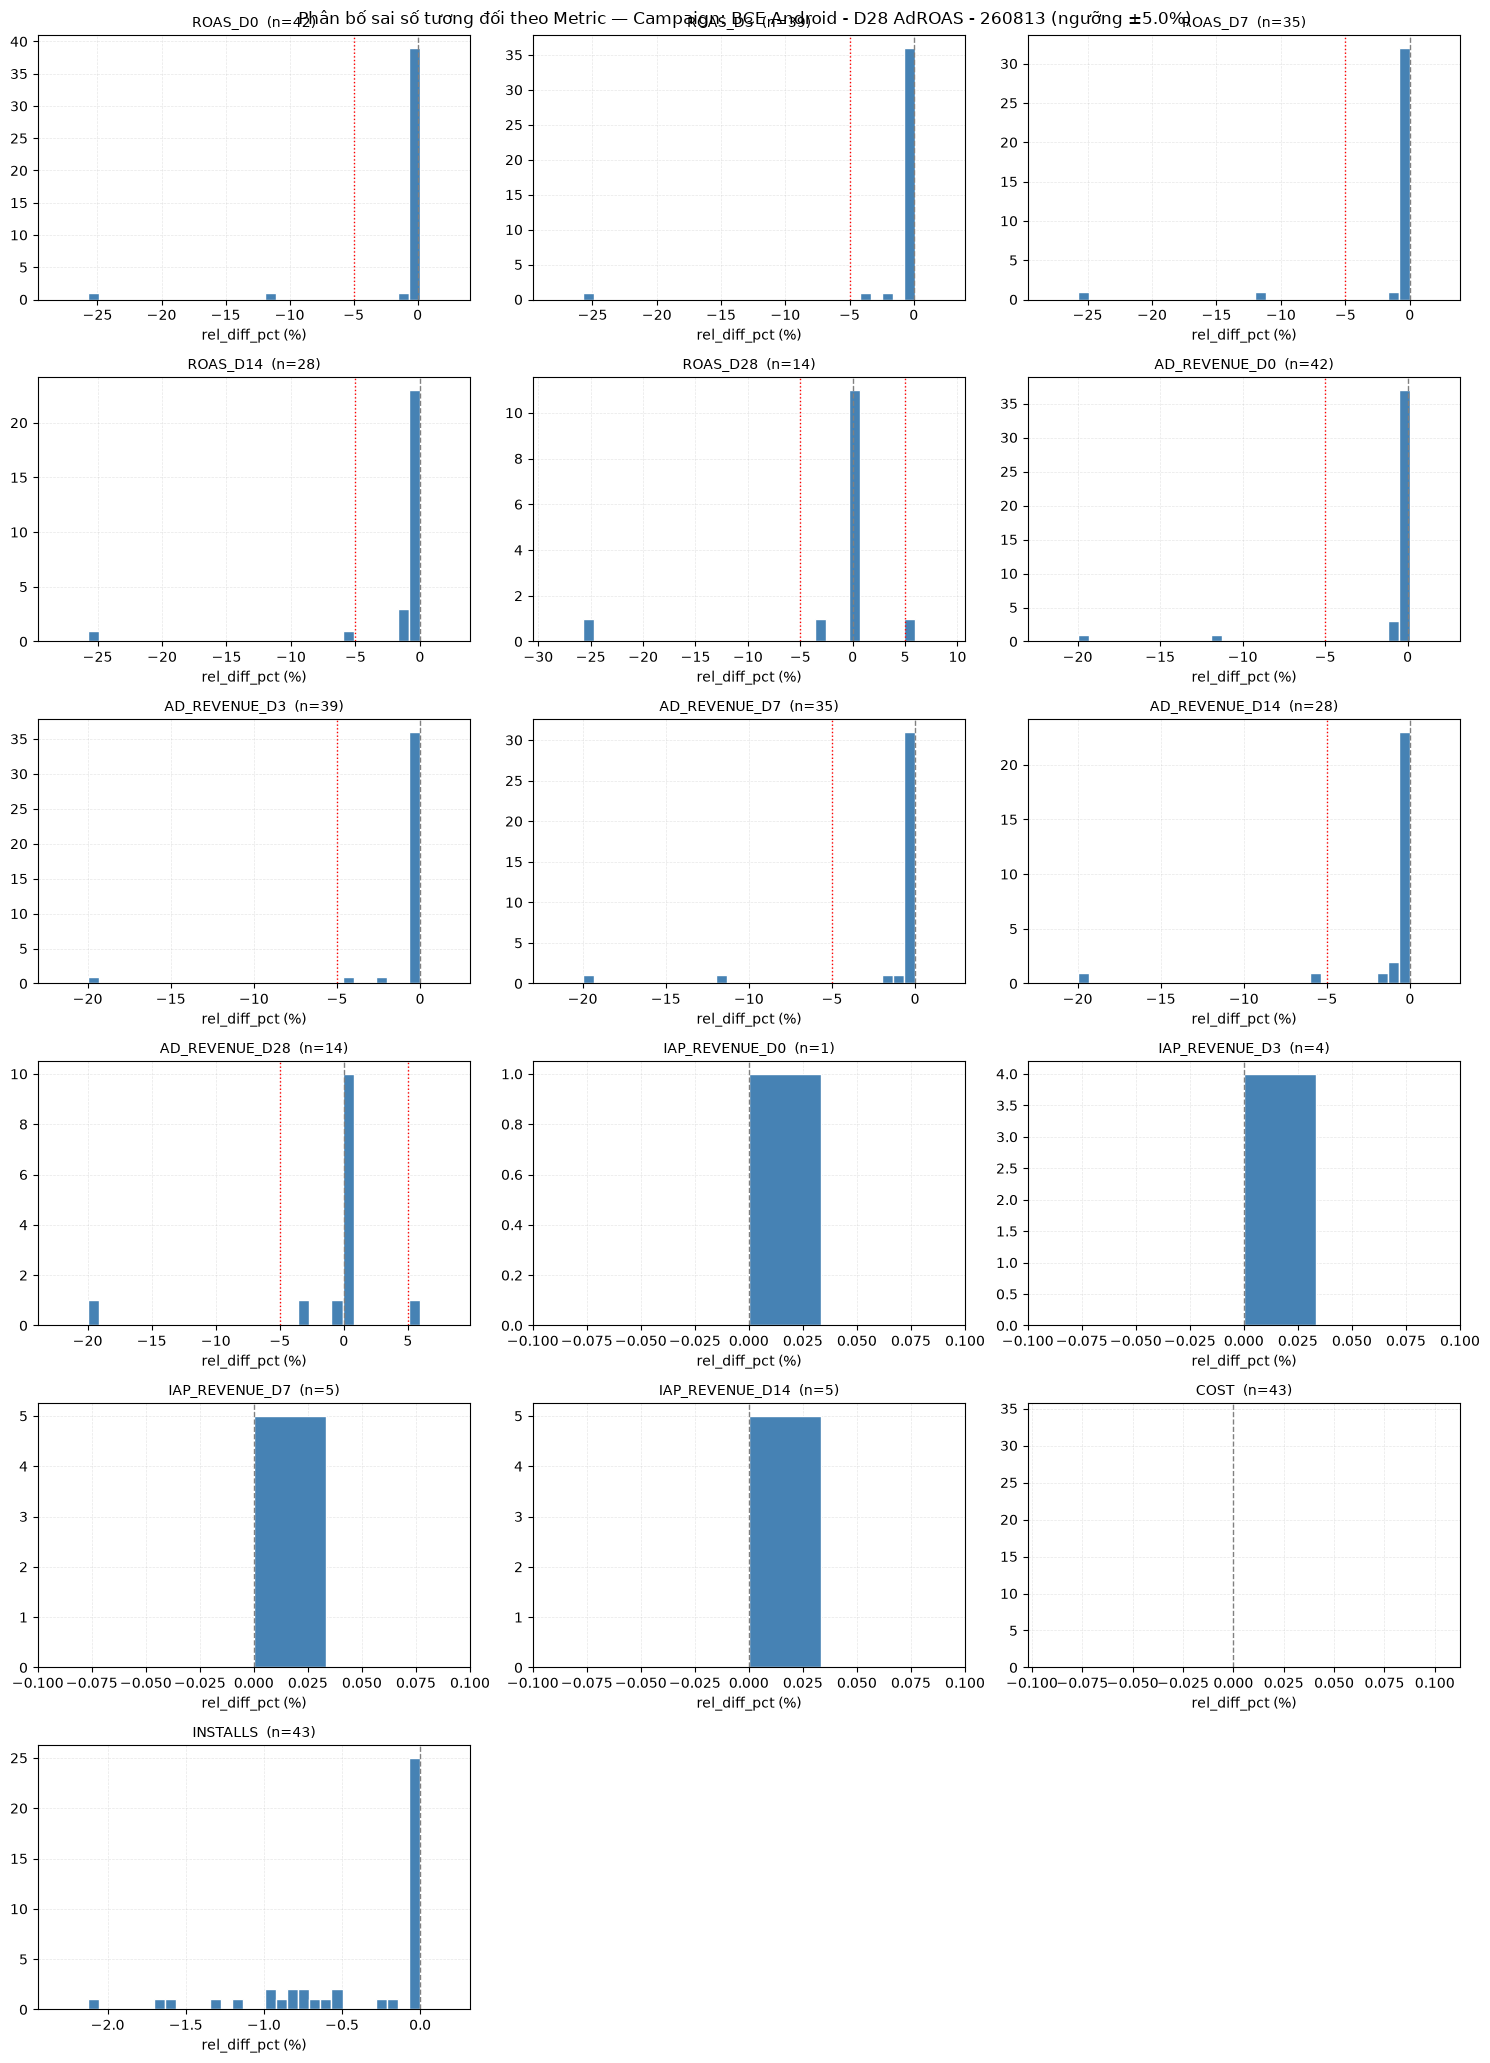

In [21]:
eda.plot_rel_diff_histogram_for_campaign(detail, campaign="BCE Android - D28 AdROAS - 260813")

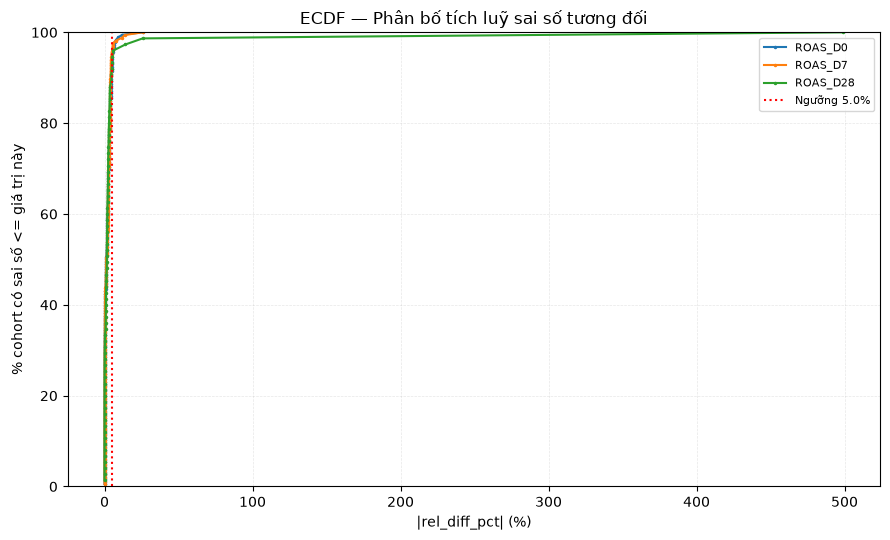

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
  metric   n  pct_within_threshold
 ROAS_D0 186                  94.1
 ROAS_D7 165                  95.8
ROAS_D28  75                  92.0


In [22]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])

In [23]:
from reconciliation.summary import iap_mismatches

iap_diff = iap_mismatches(detail)
print(f"{len(iap_diff)} dòng (cohort x metric) có IAP khác nhau")
iap_diff.to_csv(output_dir / "iap_mismatches.csv", index=False, encoding="utf-8-sig")
iap_diff


0 dòng (cohort x metric) có IAP khác nhau


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct,flag
